# Import libraries

In [1]:
import pandas as pd
import re
import missingno as msn

import pymysql
from pymysql.err import MySQLError

# Load the dataset

In [2]:
# Import dataset
df = pd.read_csv("superstore.csv",encoding="latin1")
print("Shape of dataset:", df.shape,'\n')
df.head()

Shape of dataset: (9994, 21) 



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Explore the data

In [3]:
print("\nDataset Information:")
df.info()

# rename the columns to lowercase
print("\nColumn Names:")
df.columns = (df.columns.str.strip().str.lower().str.replace(" ", "_"))
print(df.columns.tolist())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null  

# Checking and Replace null values

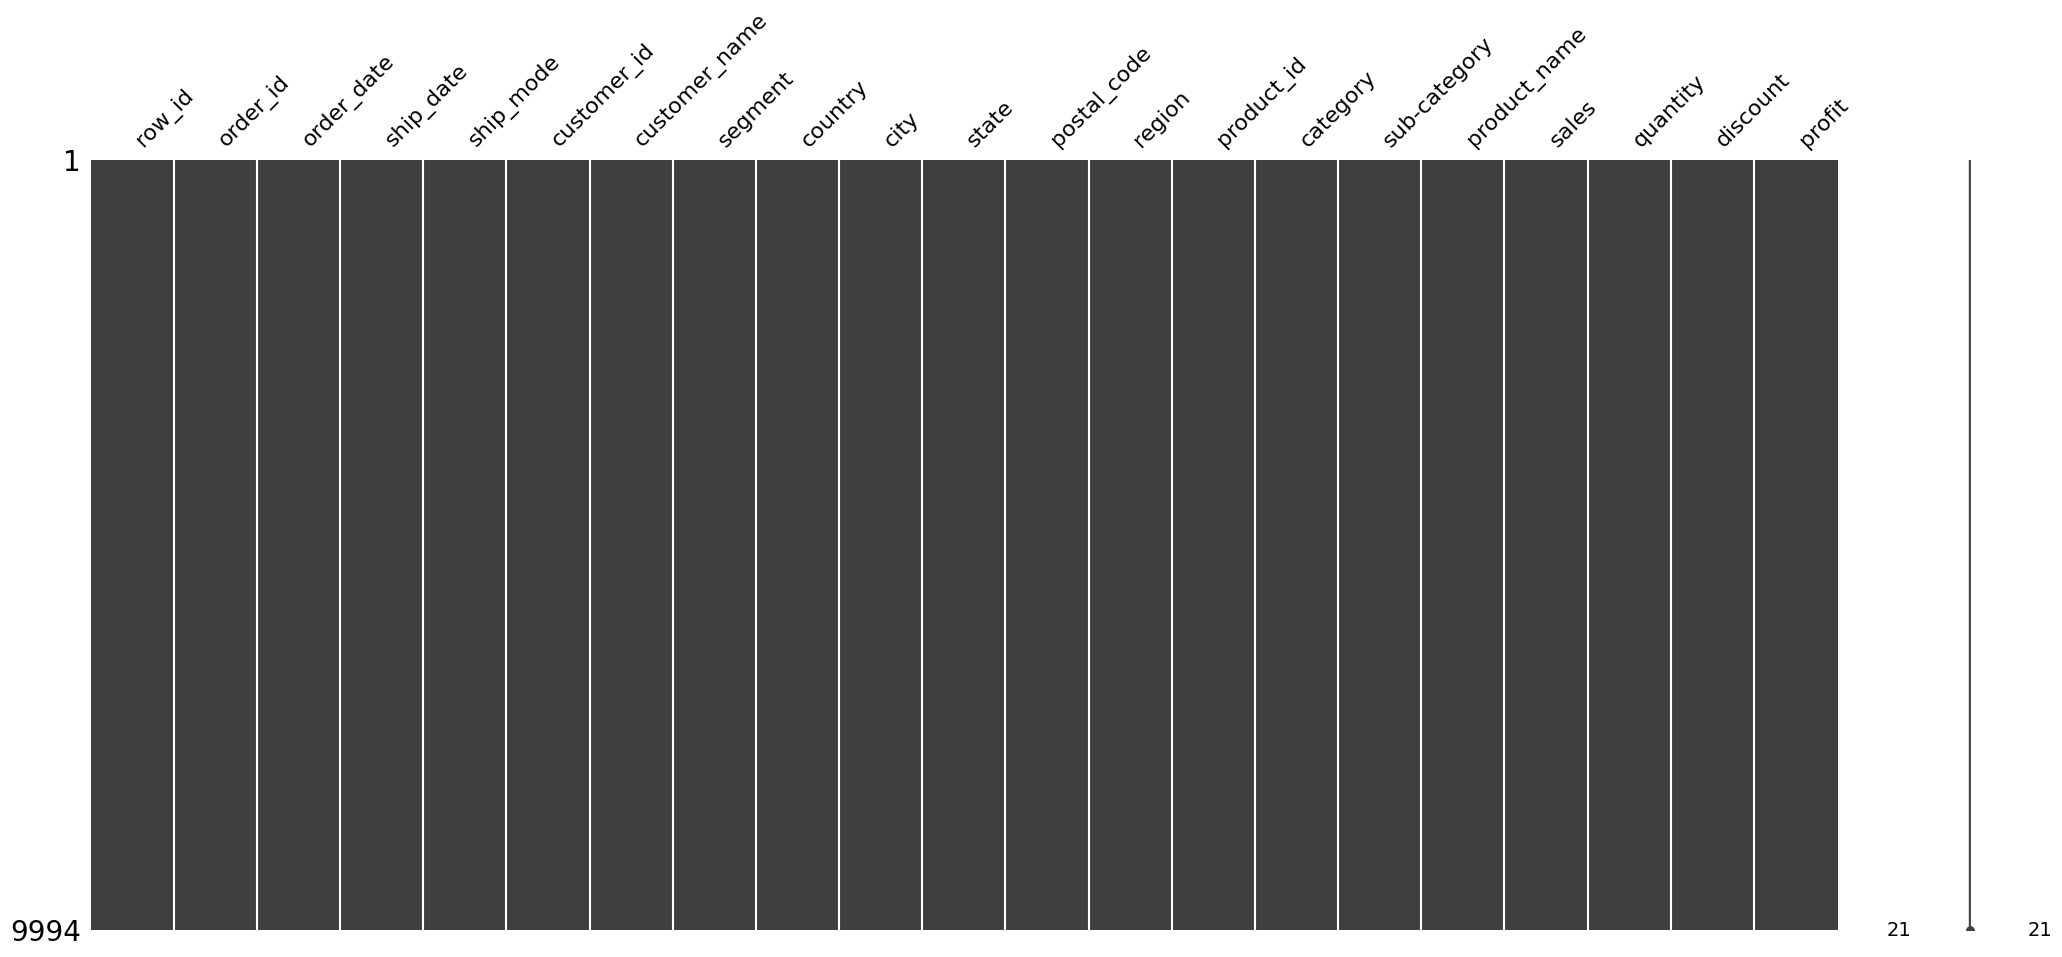

In [4]:
msn.matrix(df);

# Removing Dulipcates

In [5]:
duplicate_rows = df.duplicated()

# Count of duplicate rows
print(f"Number of duplicate rows: {duplicate_rows.sum()}")

print("Shape of DataFrame Before Removing Duplicates: ", df.shape)

# Drop the duplicates
df = df.drop_duplicates()

# Checking the shape of the data after dropping duplicates
print("Shape of DataFrame After Removing Duplicates: ", df.shape)

Number of duplicate rows: 0
Shape of DataFrame Before Removing Duplicates:  (9994, 21)
Shape of DataFrame After Removing Duplicates:  (9994, 21)


# Load data to SQL

In [6]:
mydb = pymysql.connect(
    host="localhost",
    user="root",
    password="Pkavi@1703",
)
print("Connected to Server")

cursor = mydb.cursor()

Connected to Server


In [7]:
try:
    cursor.execute("create database if not exists customer;")
    
    cursor.execute("use customer;")
    cursor.execu
        te("""CREATE TABLE Retail_Sales (
                        Row_ID  INT PRIMARY KEY,
                        Order_ID VARCHAR(20) ,
                        Order_Date DATE,
                        Ship_Date DATE,
                        Ship_Mode VARCHAR(50),
                        Customer_ID VARCHAR(20),
                        Customer_Name VARCHAR(100),
                        Segment VARCHAR(50),
                        Country VARCHAR(50),
                        City VARCHAR(50),
                        State VARCHAR(50),
                        Region VARCHAR(50),
                        Postal_Code INT,
                        Product_ID VARCHAR(20),
                        Category VARCHAR(50),
                        Sub_Category VARCHAR(50),
                        Product_Name VARCHAR(255),
                        Sales DECIMAL(10,2),
                        Quantity INT,
                        Discount DECIMAL(5,2),
                        Profit DECIMAL(10,2)
                    );   """)
    print("Connect to database")
except MySQLError as e:
    print("SQL error:", e)

SQL error: (1050, "Table 'retail_sales' already exists")


In [8]:
try:
    insert_query = """
    INSERT INTO Retail_Sales (
        Row_ID, Order_ID, Order_Date, Ship_Date, Ship_Mode, Customer_ID, Customer_Name,
        Segment, Country, City, State, Postal_Code, Region, Product_ID, Category,
        Sub_Category, Product_Name, Sales, Quantity, Discount, Profit
    ) VALUES (
        %s, %s, %s, %s, %s,
        %s, %s, %s, %s, %s,
        %s, %s, %s, %s, %s,
        %s, %s, %s, %s, %s, %s
    )
    """
    data = [tuple(row) for row in df.to_numpy()]
    cursor.executemany(insert_query, data)
    mydb.commit()
    print(f"{cursor.rowcount} rows inserted successfully!")
except MySQLError as e:
    print("SQL error:", e)


9994 rows inserted successfully!


In [9]:
if cursor:
    cursor.close()
if mydb:
    mydb.close()
print("Server Connection Closed")

Server Connection Closed
